# Machine Learning-Based Talent Scouting Classification

The aim of this project is to predict whether a football player is classified as
average or highlighted based on the evaluations provided by scouts.

The project includes data preprocessing, feature transformation, scaling,
model development, model evaluation, and feature importance analysis.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.simplefilter(action="ignore", category=Warning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
# Load the datasets

attributes = pd.read_csv(
    "scoutium_attributes.csv",
    sep=";"
)

potential_labels = pd.read_csv(
    "scoutium_potential_labels.csv",
    sep=";"
)

print("Attributes shape:", attributes.shape)
print("Potential labels shape:", potential_labels.shape)

Attributes shape: (10730, 8)
Potential labels shape: (322, 5)


## 2. Data Merging

The attribute scores and player potential labels are merged using the common identifiers of the two datasets.

In [3]:
# Merge the two datasets using common identifiers

df = pd.merge(
    attributes,
    potential_labels,
    on=[
        "task_response_id",
        "match_id",
        "evaluator_id",
        "player_id"
    ],
    how="left"
)

df.head()

,task_response_id,match_id,evaluator_id,player_id,position_id,analysis_id,attribute_id,attribute_value,potential_label
0,4915,62935,177676,1361061,2,12818495,4322,56.000,average
1,4915,62935,177676,1361061,2,12818495,4323,56.000,average
2,4915,62935,177676,1361061,2,12818495,4324,67.000,average
3,4915,62935,177676,1361061,2,12818495,4325,56.000,average
4,4915,62935,177676,1361061,2,12818495,4326,45.000,average


In [4]:
# Check the shape of the merged dataset

print("Merged dataset shape:", df.shape)

Merged dataset shape: (10730, 9)


In [5]:
# Check the structure of the merged dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10730 entries, 0 to 10729
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   task_response_id  10730 non-null  int64  
 1   match_id          10730 non-null  int64  
 2   evaluator_id      10730 non-null  int64  
 3   player_id         10730 non-null  int64  
 4   position_id       10730 non-null  int64  
 5   analysis_id       10730 non-null  int64  
 6   attribute_id      10730 non-null  int64  
 7   attribute_value   10730 non-null  float64
 8   potential_label   10730 non-null  object 
dtypes: float64(1), int64(7), object(1)
memory usage: 754.6+ KB


In [6]:
# Check potential label distribution

df["potential_label"].value_counts()

potential_label
average          8497
highlighted      2097
below_average     136
Name: count, dtype: int64

## 3. Data Filtering

Goalkeepers and the `below_average` class are removed to prepare the dataset for binary classification.

In [7]:
# Remove goalkeepers
df = df[df["position_id"] != 1]

# Remove below_average observations
df = df[df["potential_label"] != "below_average"]

# Check remaining classes
print(df["potential_label"].value_counts())

# Check final shape after filtering
print("Filtered dataset shape:", df.shape)

potential_label
average        7922
highlighted    1972
Name: count, dtype: int64
Filtered dataset shape: (9894, 9)


## 4. Pivot Table Transformation

Transform the dataset so that each row represents a player-position observation and each attribute becomes a separate feature.

In [8]:
# Create pivot table
pivot_df = df.pivot_table(
    index=[
        "player_id",
        "position_id",
        "potential_label"
    ],
    columns="attribute_id",
    values="attribute_value"
)

pivot_df.head()

attribute_id                            4322   4323   4324   4325   4326   4327   4328   4329   4330   4332   4333   4335   4338   4339   4340   4341   4342   4343   4344   4345   4348   4349   4350   4351   4352   4353   4354   4355   4356   4357   4407   4408   4423   4426
player_id position_id potential_label                                                                                                                                                                                                                                              
1355710   7           average         50.500 50.500 34.000 50.500 45.000 45.000 45.000 45.000 50.500 56.000 39.500 34.000 39.500 39.500 45.000 45.000 50.500 28.500 23.000 39.500 28.500 28.500 45.000 50.500 56.000 34.000 39.500 50.500 34.000 34.000 56.000 34.000 34.000 56.000
1356362   9           average         67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 67.000 56.000 67.000 67.000 56.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 67.000 67.000 56.000 78.000
1356375   3           average         67.000 67.000 67.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 78.000 56.000 67.000 67.000 67.000 67.000 67.000 56.000 56.000 67.000 67.000 56.000 56.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 67.000 67.000 56.000 78.000
          4           average         67.000 78.000 67.000 67.000 67.000 78.000 78.000 78.000 56.000 67.000 67.000 67.000 78.000 78.000 56.000 67.000 67.000 45.000 45.000 56.000 67.000 67.000 67.000 67.000 78.000 67.000 67.000 67.000 56.000 67.000 56.000 67.000 45.000 56.000
1356411   9           average         67.000 67.000 78.000 78.000 67.000 67.000 67.000 67.000 89.000 78.000 67.000 67.000 67.000 56.000 56.000 67.000 78.000 56.000 56.000 67.000 56.000 67.000 56.000 67.000 67.000 56.000 67.000 67.000 56.000 67.000 89.000 56.000 67.000 78.000

In [9]:
# Convert index levels back into columns
pivot_df = pivot_df.reset_index()

# Convert attribute_id column names to string
pivot_df.columns = [
    str(col)
    for col in pivot_df.columns
]

pivot_df.head()

,player_id,position_id,potential_label,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,1355710,7,average,50.500,50.500,34.000,50.500,45.000,45.000,45.000,45.000,50.500,56.000,39.500,34.000,39.500,39.500,45.000,45.000,50.500,28.500,23.000,39.500,28.500,28.500,45.000,50.500,56.000,34.000,39.500,50.500,34.000,34.000,56.000,34.000,34.000,56.000
1,1356362,9,average,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
2,1356375,3,average,67.000,67.000,67.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,78.000,56.000,67.000,67.000,67.000,67.000,67.000,56.000,56.000,67.000,67.000,56.000,56.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,67.000,67.000,56.000,78.000
3,1356375,4,average,67.000,78.000,67.000,67.000,67.000,78.000,78.000,78.000,56.000,67.000,67.000,67.000,78.000,78.000,56.000,67.000,67.000,45.000,45.000,56.000,67.000,67.000,67.000,67.000,78.000,67.000,67.000,67.000,56.000,67.000,56.000,67.000,45.000,56.000
4,1356411,9,average,67.000,67.000,78.000,78.000,67.000,67.000,67.000,67.000,89.000,78.000,67.000,67.000,67.000,56.000,56.000,67.000,78.000,56.000,56.000,67.000,56.000,67.000,56.000,67.000,67.000,56.000,67.000,67.000,56.000,67.000,89.000,56.000,67.000,78.000


## 5. Target Encoding

The target variable `potential_label` is converted into numerical form using Label Encoding.

In [10]:
# Encode the target variable

label_encoder = LabelEncoder()

pivot_df["potential_label"] = label_encoder.fit_transform(
    pivot_df["potential_label"]
)

# Check the encoded classes
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

pivot_df["potential_label"].value_counts()

{'average': np.int64(0), 'highlighted': np.int64(1)}


potential_label
0    215
1     56
Name: count, dtype: int64

## 6. Feature Scaling

Numerical predictor variables are standardized using `StandardScaler` so that the features are represented on a comparable scale.

In [11]:
# Define numerical feature columns

num_cols = [
    col for col in pivot_df.columns
    if col not in ["player_id", "potential_label"]
]

print("Number of numerical features:", len(num_cols))
print(num_cols)

Number of numerical features: 35
['position_id', '4322', '4323', '4324', '4325', '4326', '4327', '4328', '4329', '4330', '4332', '4333', '4335', '4338', '4339', '4340', '4341', '4342', '4343', '4344', '4345', '4348', '4349', '4350', '4351', '4352', '4353', '4354', '4355', '4356', '4357', '4407', '4408', '4423', '4426']


In [12]:
# Standardize numerical features

scaler = StandardScaler()

pivot_df[num_cols] = scaler.fit_transform(
    pivot_df[num_cols]
)

pivot_df.head()

,player_id,position_id,potential_label,4322,4323,4324,4325,4326,4327,4328,4329,4330,4332,4333,4335,4338,4339,4340,4341,4342,4343,4344,4345,4348,4349,4350,4351,4352,4353,4354,4355,4356,4357,4407,4408,4423,4426
0,1355710,0.511,0,-0.543,-0.559,-1.405,-0.438,-0.767,-0.795,-0.907,-0.792,-0.446,-0.123,-1.224,-1.036,-1.126,-1.009,-0.542,-0.690,-0.535,-1.067,-1.206,-1.005,-1.314,-1.042,-0.693,-0.436,0.013,-1.282,-1.132,-0.495,-1.235,-1.520,-0.143,-1.487,-0.955,-0.253
1,1356362,1.256,0,0.595,0.561,0.679,0.683,0.723,0.723,0.601,0.404,0.728,0.691,0.459,0.996,0.632,0.840,0.912,0.799,0.588,1.230,0.750,0.742,0.879,0.670,0.848,0.717,0.787,0.814,1.053,0.632,0.915,0.768,0.530,0.669,0.404,1.042
2,1356375,-0.979,0,0.595,0.561,0.679,0.683,0.723,0.723,0.601,1.002,0.728,0.691,1.132,0.319,0.632,0.840,0.912,0.799,0.588,0.574,0.750,0.742,0.879,0.670,0.077,0.717,0.787,0.814,1.053,0.632,0.915,0.768,0.530,0.669,0.404,1.042
3,1356375,-0.606,0,0.595,1.308,0.679,0.683,0.723,1.482,1.355,1.002,-0.055,0.691,0.459,0.996,1.335,1.580,0.185,0.799,0.588,-0.083,0.098,0.043,0.879,1.355,0.848,0.717,1.560,0.814,0.428,0.632,0.198,0.768,-0.143,0.669,-0.276,-0.253
4,1356411,1.256,0,0.595,0.561,1.373,1.430,0.723,0.723,0.601,0.404,2.294,1.505,0.459,0.996,0.632,0.101,0.185,0.799,1.337,0.574,0.750,0.742,0.252,1.355,0.077,0.717,0.787,0.115,0.428,0.632,0.198,0.768,1.874,-0.050,1.083,1.042


In [13]:
# Final data checks before modeling

print(
    "Missing values:",
    pivot_df.isnull().sum().sum()
)

print(
    "Remaining object columns:",
    pivot_df.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

print(
    "Dataset shape:",
    pivot_df.shape
)

Missing values: 0
Remaining object columns: []
Dataset shape: (271, 37)


## 7. Model Development

Multiple classification algorithms are evaluated using 5-fold cross-validation.  
Model performances are compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [14]:
# Define target and feature matrix

y = pivot_df["potential_label"]

X = pivot_df.drop(
    ["player_id", "potential_label"],
    axis=1
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (271, 35)
y Shape: (271,)


In [15]:
# Check target class distribution

print(y.value_counts())

print(
    y.value_counts(normalize=True)
)

potential_label
0    215
1     56
Name: count, dtype: int64
potential_label
0   0.793
1   0.207
Name: proportion, dtype: float64


In [17]:
# Define classification models

models = [
    ("Logistic Regression", LogisticRegression(random_state=17)),
    
    ("KNN", KNeighborsClassifier()),
    
    ("CART", DecisionTreeClassifier(random_state=17)),
    
    ("Random Forest", RandomForestClassifier(random_state=17)),
    
    ("SVM", SVC(
        probability=True,
        random_state=17
    )),
    
    ("GBM", GradientBoostingClassifier(random_state=17)),
    
    ("XGBoost", XGBClassifier(
        random_state=17,
        eval_metric="logloss"
    )),
    
    ("LightGBM", LGBMClassifier(
        random_state=17,
        verbose=-1
    )),
    
    ("CatBoost", CatBoostClassifier(
        random_state=17,
        verbose=False
    ))
]

In [18]:
# Define evaluation metrics

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [19]:
# Evaluate models using 5-fold cross-validation

results = []

for name, model in models:

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC_AUC": cv_results["test_roc_auc"].mean()
    })

In [20]:
# Create model comparison table

model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by="ROC_AUC",
    ascending=False
)

model_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
8,CatBoost,0.871,0.893,0.461,0.585,0.891
7,LightGBM,0.871,0.770,0.586,0.648,0.883
3,Random Forest,0.871,0.860,0.461,0.584,0.883
4,SVM,0.849,1.000,0.267,0.415,0.871
5,GBM,0.867,0.760,0.530,0.610,0.869
6,XGBoost,0.860,0.764,0.550,0.614,0.866
0,Logistic Regression,0.845,0.683,0.482,0.555,0.834
1,KNN,0.838,0.817,0.265,0.390,0.773
2,CART,0.797,0.551,0.568,0.540,0.712


### Model Evaluation

CatBoost achieved the highest ROC-AUC score (0.891), while LightGBM achieved the highest F1 score (0.648) and recall (0.586).

Although CatBoost showed the strongest overall class discrimination, LightGBM provided a better balance between precision and recall for identifying highlighted players.

## 8. Feature Importance

LightGBM is selected for feature importance analysis due to its strong ROC-AUC performance and the best balance between precision and recall, reflected by the highest F1 score.

In [21]:
# Train the final LightGBM model

final_model = LGBMClassifier(
    random_state=17,
    verbose=-1
)

final_model.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [22]:
# Create feature importance dataframe

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
0,position_id,96
4,4325,88
13,4338,63
31,4407,59
7,4328,53
26,4353,52
19,4344,52
1,4322,52
33,4423,51
12,4335,49


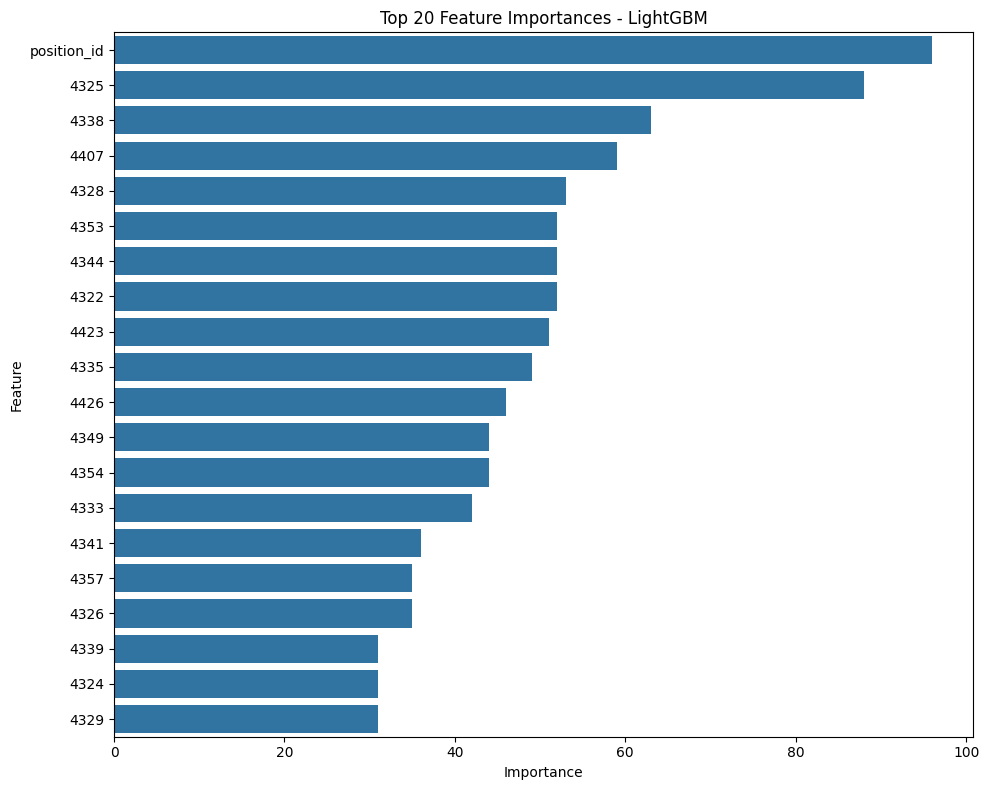

In [23]:
# Visualize the top 20 most important features

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Evaluation

`position_id` was identified as the most influential feature in the LightGBM model.

Among the scout evaluation attributes, `4325`, `4338`, `4407`, and `4328` were among the most important predictors. This indicates that both player position and specific scout evaluation scores contribute substantially to the classification of player potential.

## 9. Conclusion

In this project, scout evaluations were used to classify football players as `average` or `highlighted`.

After data preprocessing and transformation, multiple classification algorithms were evaluated using 5-fold cross-validation. CatBoost achieved the highest ROC-AUC score (0.891), while LightGBM achieved the highest F1 score (0.648) and recall (0.586).

LightGBM was selected for the final analysis because it provided a strong balance between precision and recall in identifying highlighted players.

Feature importance analysis showed that `position_id` was the most influential predictor, followed by several scout evaluation attributes such as `4325`, `4338`, `4407`, and `4328`.